# Bottom age tracer in ACCESS-CM3 `cm3-run-11-08-2025-25km-beta-om3-new-um-params` test run output using intake

This notebook plots the bottom age tracer in the Southern Ocean from the ACCESS-CM3 `cm3-run-11-08-2025-25km-beta-om3-new-um-params` test run. 

This notebook is based on the [Bottom_age_tracer_in_ACCESS_OM3.ipynb](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/blob/main/notebooks/Bottom_age_tracer_in_ACCESS_OM3.ipynb) used for the OM3-25km evaluation.

A comparison to OM3-25km is included (MC_25km_jra_iaf-1.0-beta-5165c0f8).

In [1]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'

# esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-virtual-datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-cm3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /g/data/x77/wgh581/access-cm3-paper-figs/


In [34]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import numpy as np
import cmocean as cm

In [3]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41613 instead
  warnings.warn(


/proxy/41613/status


2026-01-19 15:00:05,026 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:43897 (pid=1291256) exceeded 95% memory budget. Restarting...
2026-01-19 15:00:05,088 - distributed.nanny - WARNING - Restarting worker
2026-01-19 15:00:07,030 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:41523 (pid=1291297) exceeded 95% memory budget. Restarting...
2026-01-19 15:00:07,154 - distributed.nanny - WARNING - Restarting worker
2026-01-19 15:00:09,820 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:41691 (pid=1291258) exceeded 95% memory budget. Restarting...
2026-01-19 15:00:09,938 - distributed.nanny - WARNING - Restarting worker
2026-01-19 15:00:12,564 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:46163 (pid=1291240) exceeded 95% memory budget. Restarting...
2026-01-19 15:00:12,644 - distributed.scheduler - ERROR - Task concatenate-getitem-open_dataset-agessc-original-finalize-hlgfinalizecompute-d0ead1be981a41d8a92f5420d2b3f82e marked as fai

### Open the intake-esm datastore

In [4]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

### Load bottom age tracer

#### CM3

In [14]:
age_CM3 = datastore.search(variable="agessc", frequency="1mon", variable_cell_methods="area:mean z_l:mean yh:mean xh:mean time: mean").to_dask(
    xarray_open_kwargs = dict(
        chunks={"yh": 100, "xh": 360, "time":-1},
        # chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        # chunks={"time": -1}, # Good for temporal operations, but not spatial
        decode_timedelta=True
    )
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [16]:
age_CM3_2030 = age_CM3.agessc.sel(yh=slice(-90,-50)).sel(time=slice('2030-01-01','2030-12-31'))

In [18]:
age_CM3_2030 = age_CM3_2030.mean('time').load()

Get bottom tracer

In [20]:
depth_array = age_CM3_2030 * 0 + age_CM3_2030.z_l
max_depth   = depth_array.max(dim='z_l', skipna=True)

In [21]:
age_CM3_bot_2030 = age_CM3_2030.where(depth_array.z_l >= max_depth)
age_CM3_bot_2030 = age_CM3_bot_2030.sum(dim='z_l').load()

Normalise age tracer by max value

In [24]:
age_CM3_bot_2030_normalised = age_CM3_bot_2030/age_CM3_bot_2030.max()

Mask contiental shelf

In [25]:
# Load shelf mask: 1000 m isobath for OM3-25km grid, created using this notebook: Calc_OM3_25km_1000m_isobath_contour.ipynb (add to repository?)
contour_masked_above = xr.open_mfdataset('/g/data/x77/wgh581/Post_Process/DSW_in_025_models/Antarctic_slope_contour_1000m_OM3_25km.nc').contour_masked_above

shelf_mask = contour_masked_above.where(contour_masked_above==0, 1)
shelf_mask = shelf_mask.where(shelf_mask==1)

In [26]:
age_CM3_bot_2030_masked = age_CM3_bot_2030_normalised*shelf_mask

#### OM3

In [36]:
om3_file='/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json'

In [37]:
datastore_om3 = intake.open_esm_datastore(
    om3_file,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
    ]
)

In [ ]:
age_OM3 = datastore_om3.search(variable="agessc", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"yh": 100, "xh": 360, "time":-1}, 
        decode_timedelta=True
    )
)

In [39]:
age_OM3_2014 = age_OM3.agessc.sel(yh=slice(-90,-50)).sel(time=slice('2014-01-01','2014-12-31'))
age_OM3_2014 = age_OM3_2014.mean('time').load()

Get bottom tracer

In [40]:
depth_array = age_OM3_2014 * 0 + age_OM3_2014.z_l
max_depth   = depth_array.max(dim='z_l', skipna=True)

In [41]:
age_bot_2014 = age_OM3_2014.where(depth_array.z_l >= max_depth)
age_bot_2014 = age_bot_2014.sum(dim='z_l').load()

Normalise age tracer by max value

In [42]:
age_bot_2014_normalised = age_bot_2014/age_bot_2014.max()

Mask contiental shelf

In [43]:
age_bot_2014_masked = age_bot_2014_normalised*shelf_mask

### Plotting

In [48]:
# Land mask
var_search = datastore.search(variable="deptho")
ds = var_search.search(path=var_search.df.path[0]).to_dask() # we only need one file as bathymetry doesn't change
bathymetry = ds["deptho"].load()
land = xr.where(np.isnan(bathymetry.rename("land")), 1, np.nan)
land = land.sel(yh=slice(-90,-50))

ft_size = 12 # fontsize
fig_path = '/g/data/x77/wgh581/Figures/Figures_access-cm3-paper1/'

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:101: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_dataset(url, **xarray_open_kwargs)


In [32]:
# 1000 m contour
slope_contour = contour_masked_above.where(contour_masked_above>0)
slope_contour = slope_contour/slope_contour

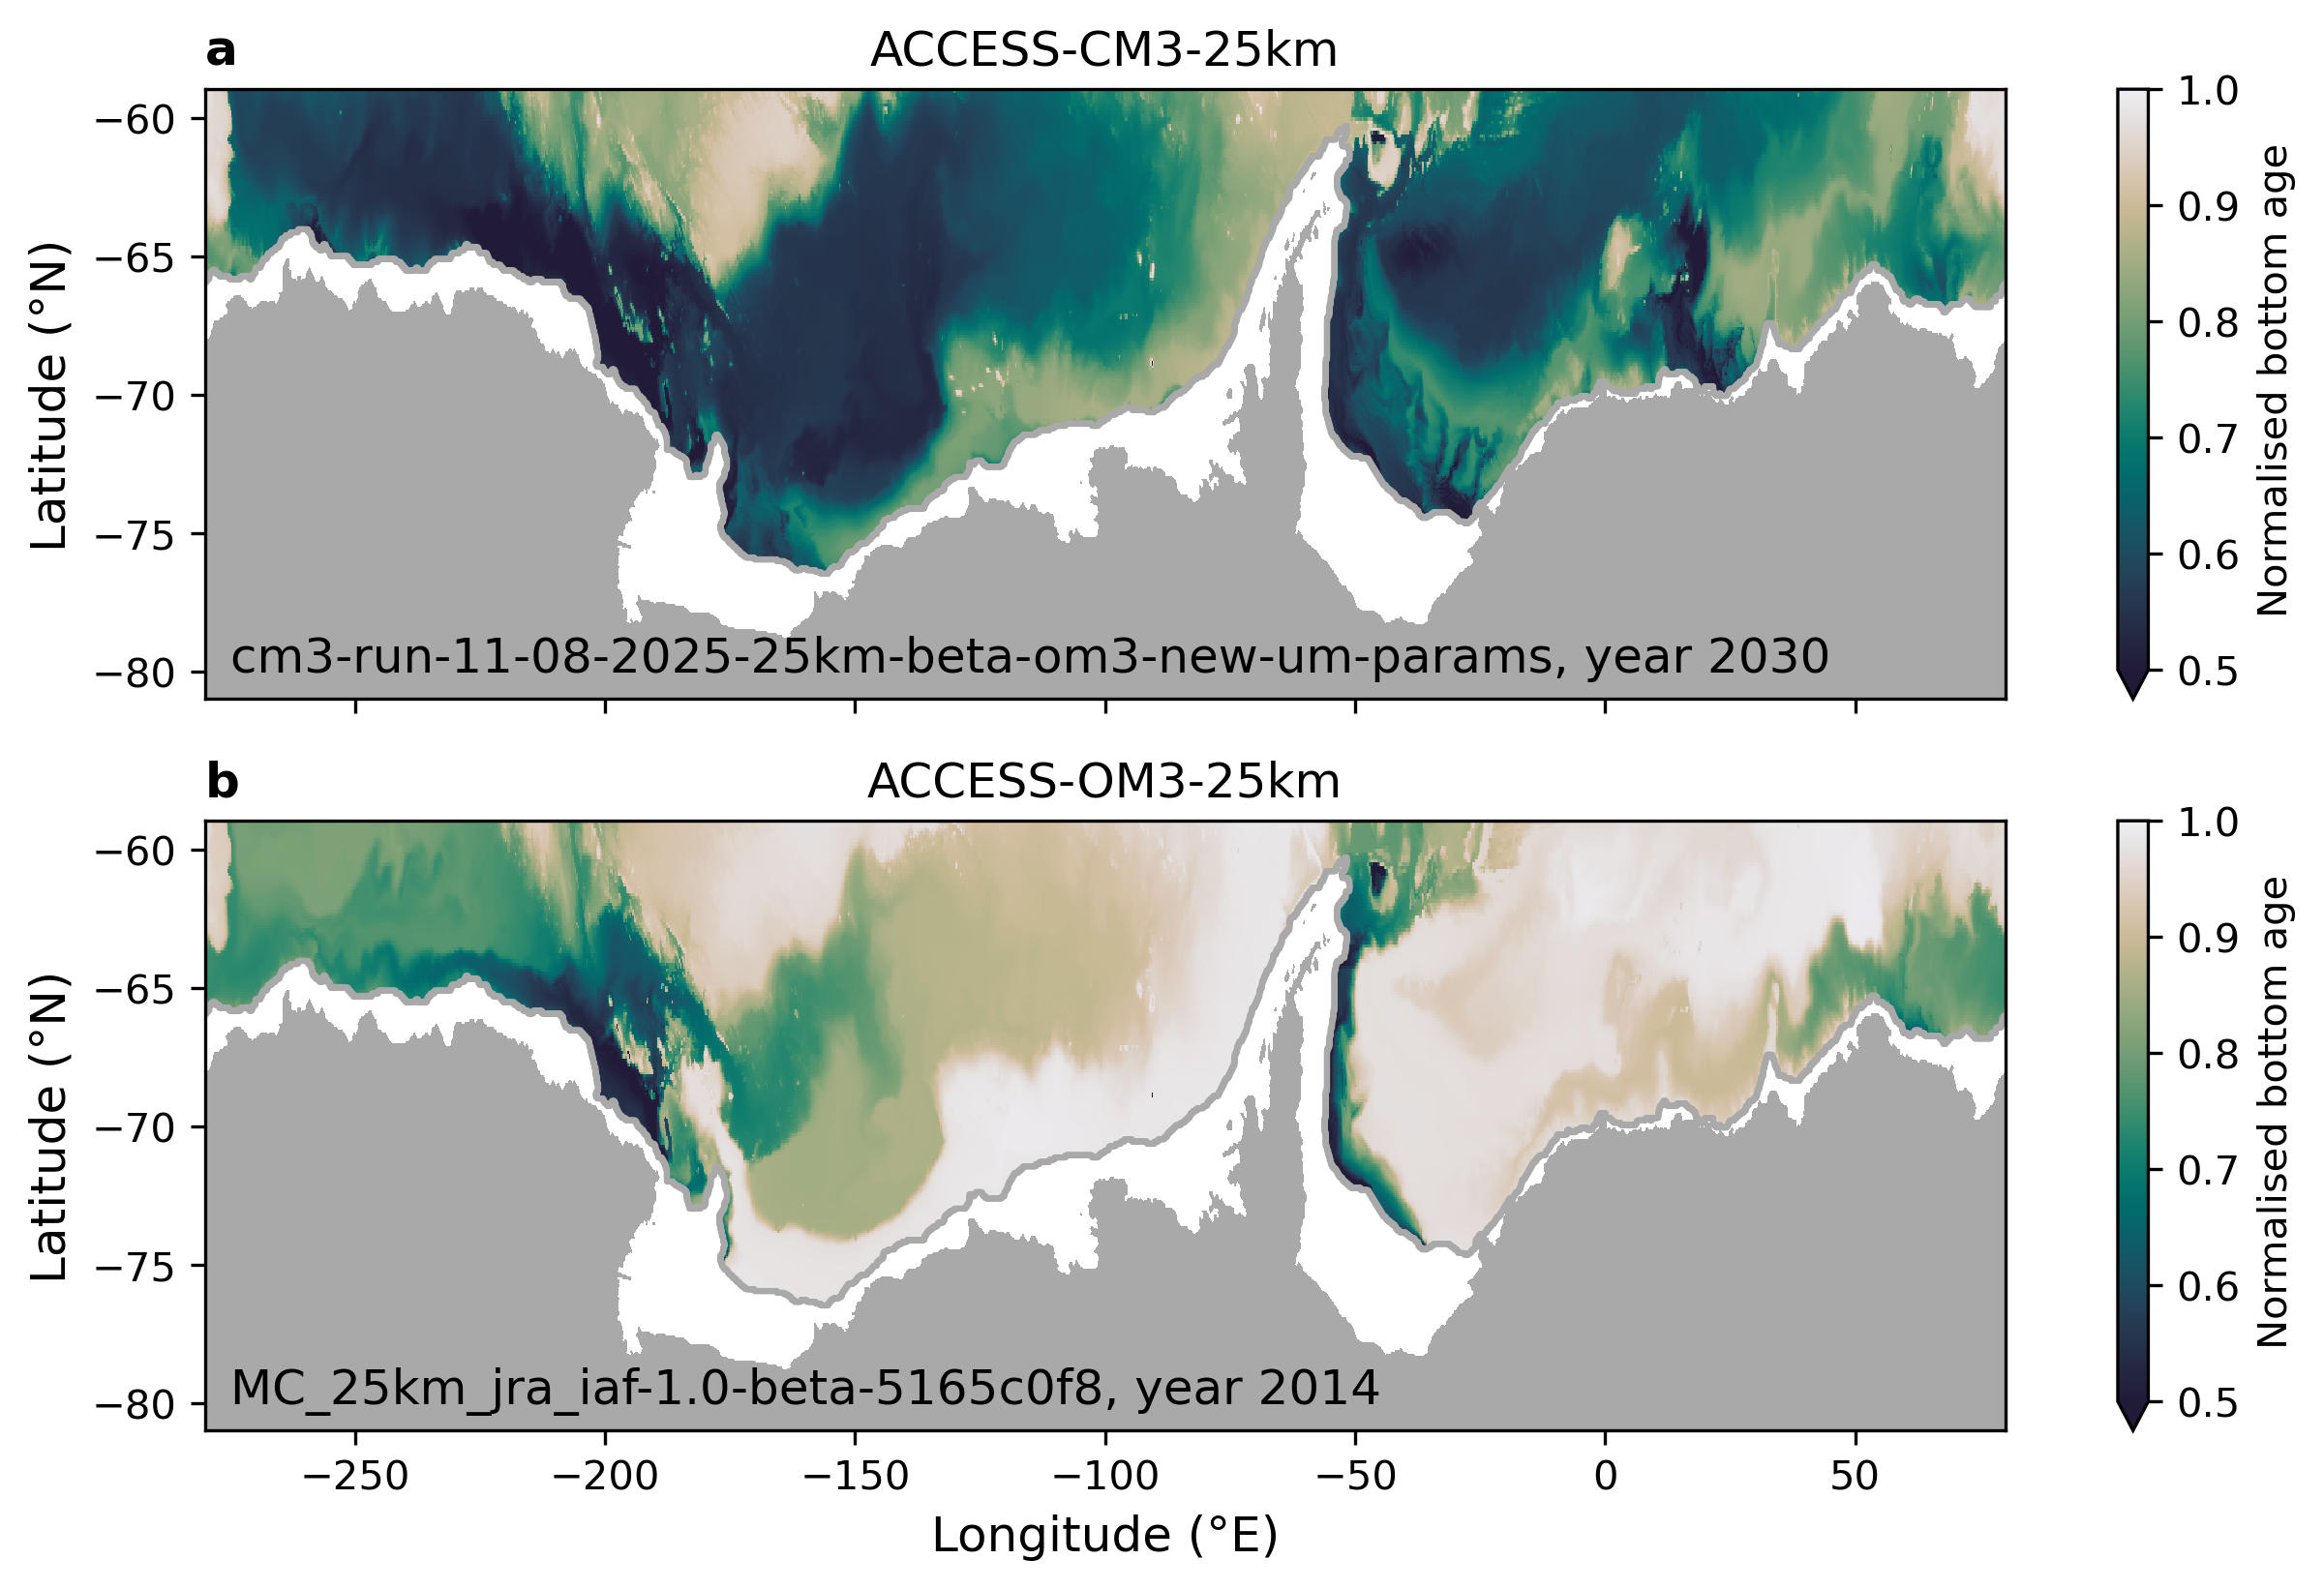

In [49]:
plt.figure(figsize=(10, 6))

plt.subplot(211)
land.plot.contourf(colors="darkgrey", add_colorbar=False)
age_CM3_bot_2030_masked.plot(cmap=cm.cm.rain_r, vmin=0.5, vmax=1, cbar_kwargs={'label': "Normalised bottom age"})
slope_contour.fillna(2).plot.contour(levels=[0,1], colors='darkgrey', linewidths=1.5)
plt.title('ACCESS-CM3-25km'), plt.title('a', fontweight='bold', fontsize=ft_size, loc='left')
plt.tick_params(labelbottom=False)
plt.xlabel(''), plt.ylabel('Latitude (°N)', fontsize=ft_size)
plt.text(-275, -80, 'cm3-run-11-08-2025-25km-beta-om3-new-um-params, year 2030', fontsize=ft_size)

plt.subplot(212)
land.plot.contourf(colors="darkgrey", add_colorbar=False)
age_bot_2014_masked.plot(cmap=cm.cm.rain_r, vmin=0.5, vmax=1, cbar_kwargs={'label': "Normalised bottom age"})
slope_contour.fillna(2).plot.contour(levels=[0,1], colors='darkgrey', linewidths=1.5)
plt.title('ACCESS-OM3-25km'), plt.title('b', fontweight='bold', fontsize=ft_size, loc='left')
plt.xlabel('Longitude (°E)', fontsize=ft_size), plt.ylabel('Latitude (°N)', fontsize=ft_size)
plt.text(-275, -80, 'MC_25km_jra_iaf-1.0-beta-5165c0f8, year 2014', fontsize=ft_size)

# Save figure
save_flag = 1
if save_flag == 1:
    plt.savefig(fig_path + 'Fig_bottom_age_CM3_OM3.png', dpi=300, bbox_inches='tight', facecolor='white');